# Featural Similarity versus Vector Space Model Similarity

In [23]:
import pandas as pd
from pathlib import Path
from gensim.models import KeyedVectors
import gensim.downloader as api
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

# Optional: progress bar for pandas apply
tqdm.pandas()

In [24]:
# Load models

# Static vector
model1 = api.load("word2vec-google-news-300")

# Contextual vectors
model2 = SentenceTransformer("all-MiniLM-L6-v2")
model3 = SentenceTransformer('all-mpnet-base-v2')

In [25]:
# Load word pair lists

folder = Path("../exp_files/01_experiment")
files = sorted(folder.glob("*.csv"))

row_counts = {f.name: len(pd.read_csv(f)) for f in files}
row_counts

{'a2_ConceptualMatchingOnly_Physical.csv': 100,
 'a2_ConceptualMatchingOnly_Social.csv': 100,
 'a2_MaxMatch_Negative_Physical.csv': 45,
 'a2_MaxMatch_Negative_Social.csv': 45,
 'a2_MaxMatch_Positive_Physical.csv': 45,
 'a2_MaxMatch_Positive_Social.csv': 45,
 'a2_MaxMismatch.csv': 100,
 'a2_SelfPair.csv': 40,
 'a2_ValenceMatchingOnly_Negative.csv': 100,
 'a2_ValenceMatchingOnly_Positive.csv': 100,
 'a_ConceptualMatchingOnly_Abstract.csv': 100,
 'a_ConceptualMatchingOnly_Concrete.csv': 100,
 'a_MaxMatch_Negative_Abstract.csv': 45,
 'a_MaxMatch_Negative_Concrete.csv': 45,
 'a_MaxMatch_Positive_Abstract.csv': 45,
 'a_MaxMatch_Positive_Concrete.csv': 45,
 'a_MaxMismatch.csv': 100,
 'a_SelfPair.csv': 40,
 'a_ValenceMatchingOnly_Negative.csv': 100,
 'a_ValenceMatchingOnly_Positive.csv': 100,
 'n2_ConceptualMatchingOnly_Animate.csv': 100,
 'n2_ConceptualMatchingOnly_Inanimate.csv': 100,
 'n2_MaxMatch_Negative_Animate.csv': 45,
 'n2_MaxMatch_Negative_Inanimate.csv': 45,
 'n2_MaxMatch_Positive_A

In [26]:
# Concat them all together
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Model 1: word-2-vec

In [27]:
def get_similarity(w1, w2):
    if w1 in model1 and w2 in model1:
        return model1.similarity(w1, w2)
    else:
        return None  # or 0, or np.nan
df["W2VSimilarity"] = df.apply(lambda row: get_similarity(row["Word1"], row["Word2"]), axis=1)

df.head()

,Word1,Word2,FeatureCombo1,FeatureCombo2,FeatureMatch,Valence,Conceptual,Group,W2VSimilarity
0,moldy,fluffy,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.288006
1,moldy,sunny,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.148399
2,moldy,blooming,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.153378
3,moldy,floral,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.074887
4,moldy,oceanic,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.094232


<Axes: ylabel='Density'>

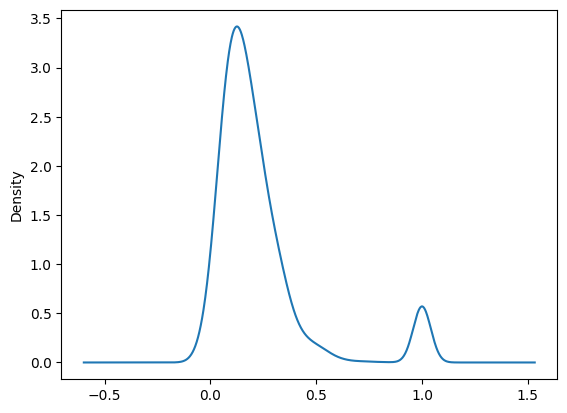

In [28]:
df["W2VSimilarity"].plot.kde()

In [29]:
df["W2VSimilarity"].isnull().values.any()

True

In [30]:
# Assuming df is your DataFrame
nan_combos = df[df["W2VSimilarity"].isna()][["Word1", "Word2"]]
print(nan_combos)

          Word1     Word2
1546     heroin  doughnut
1556   swastika  doughnut
1566    wiretap  doughnut
1576    cocaine  doughnut
1586  excrement  doughnut
1596     poison  doughnut
1606    gunshot  doughnut
1616      flood  doughnut
1626   smallpox  doughnut
1636     corpse  doughnut
1780      prize  doughnut
1788   sunshine  doughnut
1795      award  doughnut
1801      pizza  doughnut
1806   laughter  doughnut
1810      feast  doughnut
1814   doughnut    dollar
1815   doughnut  sandwich
1816   doughnut    meadow
1936   doughnut  doughnut
2120   doughnut  comedian
2121   doughnut     puppy
2122   doughnut   sibling
2123   doughnut  duckling
2124   doughnut    kitten
2125   doughnut     bunny
2126   doughnut     child
2127   doughnut  princess
2128   doughnut  chipmunk
2129   doughnut   husband


# Model 2: Sentence Transformer (smaller)

- MiniLM architecture with 6 transformer layers and 384-dimensional embeddings
- Model Card: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

In [31]:
# Compute similarities
def get_similarity(w1, w2):
    v1 = model2.encode(w1)
    v2 = model2.encode(w2)
    return cosine_similarity([v1], [v2])[0][0]

df["BertSimilarity1"] = df.apply(lambda row: get_similarity(row["Word1"], row["Word2"]), axis=1)

df.head()

,Word1,Word2,FeatureCombo1,FeatureCombo2,FeatureMatch,Valence,Conceptual,Group,W2VSimilarity,BertSimilarity1
0,moldy,fluffy,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.288006,0.402659
1,moldy,sunny,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.148399,0.184858
2,moldy,blooming,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.153378,0.295470
3,moldy,floral,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.074887,0.325189
4,moldy,oceanic,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.094232,0.252894


# Model 3: Sentence Transformer Model (bigger)
- MPNet with 12 transformer layers and 768-dimensional embeddings
- Model card: https://huggingface.co/sentence-transformers/all-mpnet-base-v2

In [32]:

# Load SBERT model
# model = SentenceTransformer('all-mpnet-base-v2')

# Faster approach: encode each unique word once
unique_words = pd.unique(df[["Word1", "Word2"]].values.ravel())

# Create embedding dictionary
embeddings = {
    word: model3.encode(str(word), convert_to_numpy=True)
    for word in unique_words
}

# Similarity function
def get_similarity_fast(w1, w2):
    v1 = embeddings[w1]
    v2 = embeddings[w2]
    return cosine_similarity([v1], [v2])[0][0]

# Compute similarities
df["BertSimilarity2"] = df.apply(
    lambda row: get_similarity_fast(row["Word1"], row["Word2"]),
    axis=1
)

# View results
df.head()

,Word1,Word2,FeatureCombo1,FeatureCombo2,FeatureMatch,Valence,Conceptual,Group,W2VSimilarity,BertSimilarity1,BertSimilarity2
0,moldy,fluffy,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.288006,0.402659,0.262211
1,moldy,sunny,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.148399,0.184858,0.264408
2,moldy,blooming,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.153378,0.295470,0.269461
3,moldy,floral,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.074887,0.325189,0.250247
4,moldy,oceanic,physical-negative,physical-positive,ConceptualMatchingOnly,NegativeMismatch,ConceptualMatch:physical,NaN,0.094232,0.252894,0.213383


In [33]:
len(df)

4720

In [34]:
df.to_csv("../exp_files/vector_space_similarity.csv")